# Thesis Figures
Generation of publication-quality figures for the thesis.
Loads pre-processed windowed signals and generates segmentation figures.

## 1. Imports and configuration

In [1]:
import pickle
import logging
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Union
import numpy as np

from src import (
    plot_station_windows,
    plot_station_windows_multitype,
    plot_multiple_stations,
    convert_signals_to_dict,
    add_time_columns,
    plot_ar_aic_onset_detection,
    plot_scaling_curves_v2,
    plot_scaling_exponents_v2
)

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
# ── Project paths ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

THESIS_FIGURES_DIR = PROJECT_ROOT / 'figures' / 'thesis'
THESIS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PAPER_FIGURES_DIR = PROJECT_ROOT / 'figures' / 'paper'
PAPER_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

POSTER_FIGURES_DIR = PROJECT_ROOT / 'figures' / 'poster'
POSTER_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Signal configuration ──────────────────────────────────────────────────────
SIGNAL_TYPES = ['acceleration', 'velocity', 'displacement']

SIGNAL_UNITS = {
    'acceleration': 'cm/s²',
    'velocity':     'cm/s',
    'displacement': 'cm',
}

SIGNAL_COLUMNS = {
    'acceleration': 'acceleration',
    'velocity':     'velocity',
    'displacement': 'displacement',
}

# ── Helper: build processed data paths ───────────────────────────────────────
def get_ar_aic_windowed_path(event_id: str, signal_type: str, coda_method: str, config: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '03a_phase_identification_ar_pick' / config / signal_type
        / f'windowed_{signal_type}_{coda_method}_ar_pick.pkl'
    )

def get_phasenet_windowed_path(event_id: str, signal_type: str, phasenet_config: str, coda_method: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '03b_phase_identification_phasenet' / phasenet_config / signal_type
        / f'windowed_{signal_type}_{coda_method}_phasenet.pkl'
    )

def get_signals_path(event_id: str, signal_type: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '01b_signals' / signal_type
        / f'{signal_type[:3]}_preprocessed_scaling.parquet'
    )

def get_metadata_path(event_id: str, signal_type: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '01a_metadata' / signal_type
        / f'metadata_clean_{signal_type[:3]}.parquet'
    )

# ── Helper: load windowed signals ─────────────────────────────────────────────
def load_windowed(path: Path) -> dict:
    with open(path, 'rb') as f:
        return pickle.load(f)

# ── Helper: load signals dict for all three signal types ─────────────────────
from src import add_time_columns, convert_signals_to_dict, get_station_from_filename

def load_signals_dicts(event_id: str) -> dict:
    signals_dicts = {}
    df_meta = pd.read_parquet(get_metadata_path(event_id, 'acceleration'))
    for st in SIGNAL_TYPES:
        df = pd.read_parquet(get_signals_path(event_id, st))
        df = add_time_columns(
            df,
            df_meta,
            time_col='DATE_TIME_FIRST_SAMPLE',
            sampling_interval_col='SAMPLING_INTERVAL_S',
        )
        signals_dicts[st] = convert_signals_to_dict(
            df, signal_column=SIGNAL_COLUMNS[st]
        )
    return signals_dicts

# ── Helper: load windowed signals for all three signal types ──────────────────
def load_windowed_dicts_ar_aic(event_id: str, coda_method: str, config: str) -> dict:
    return {
        st: load_windowed(get_ar_aic_windowed_path(event_id, st, coda_method, config))
        for st in SIGNAL_TYPES
    }

def load_windowed_dicts_phasenet(event_id: str, phasenet_config: str, coda_method: str) -> dict:
    return {
        st: load_windowed(get_phasenet_windowed_path(event_id, st, phasenet_config, coda_method))
        for st in SIGNAL_TYPES
    }

def get_ar_aic_results_path(event_id: str, signal_type: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '03a_phase_identification_ar_pick' / signal_type
        / f'onsets_ar_pick_{signal_type[:3]}.parquet'
    )


## 2. INT-41004391 (Queyras, Mw 3.8)

In [ ]:
EVENT_ID_QUEYRAS = 'INT-41004391'
STATION_QUEYRAS  = 'OGDI'
CODA_METHOD      = 'rautian'
mode='thesis'

FIGURES_QUEYRAS = THESIS_FIGURES_DIR / EVENT_ID_QUEYRAS / 'segmentation'
FIGURES_QUEYRAS.mkdir(parents=True, exist_ok=True)

# Load metadata and signals
df_meta_queyras = pd.read_parquet(
    get_metadata_path(EVENT_ID_QUEYRAS, 'acceleration')
)
signals_dicts_queyras = load_signals_dicts(EVENT_ID_QUEYRAS)
logger.info(f"Loaded signals for {EVENT_ID_QUEYRAS}")

### 2.1 AR-AIC segmentation

In [ ]:
windowed_ar_aic_queyras = load_windowed_dicts_ar_aic(EVENT_ID_QUEYRAS, CODA_METHOD)
logger.info("Loaded AR-AIC windowed signals for Queyras")
plt.close('all')
fig = plot_station_windows_multitype(
    station=STATION_QUEYRAS,
    signals_dicts=signals_dicts_queyras,
    windowed_signals_dicts=windowed_ar_aic_queyras,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_queyras,
    coda_method=CODA_METHOD,
    title_suffix='AR-AIC onsets',
    output_path=FIGURES_QUEYRAS / f'{STATION_QUEYRAS}_ar_aic_{CODA_METHOD}',
    mode=mode,
)
plt.show()

### 2.3 PhaseNet segmentation — threshold configuration

In [ ]:
PHASENET_CONFIG = 'thresh_30'

windowed_phasenet_thresh_queyras = load_windowed_dicts_phasenet(
    EVENT_ID_QUEYRAS, PHASENET_CONFIG, CODA_METHOD
)
logger.info("Loaded PhaseNet threshold windowed signals for Queyras")
plt.close('all')
fig = plot_station_windows_multitype(
    station=STATION_QUEYRAS,
    signals_dicts=signals_dicts_queyras,
    windowed_signals_dicts=windowed_phasenet_thresh_queyras,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_queyras,
    coda_method=CODA_METHOD,
    title_suffix='PhaseNet onsets',
    output_path=FIGURES_QUEYRAS / f'{STATION_QUEYRAS}_phasenet_thresh_{CODA_METHOD}',
    mode=mode,
)
plt.show()

## 3. IT-2009-0009 (L'Aquila, Mw 6.1)

In [ ]:
EVENT_ID_LAQUILA = 'IT-2009-0009'
STATION_LAQUILA  = 'SPO'  # update after station selection
CODA_METHOD      = 'rautian'

FIGURES_LAQUILA = THESIS_FIGURES_DIR / EVENT_ID_LAQUILA / 'segmentation'
FIGURES_LAQUILA.mkdir(parents=True, exist_ok=True)

df_meta_laquila = pd.read_parquet(
    get_metadata_path(EVENT_ID_LAQUILA, 'acceleration')
)
signals_dicts_laquila = load_signals_dicts(EVENT_ID_LAQUILA)
logger.info(f"Loaded signals for {EVENT_ID_LAQUILA}")

### 3.1 AR-AIC segmentation

In [ ]:
AR_AIC_CONFIG = 'no_filter'

In [ ]:
windowed_ar_aic_laquila = load_windowed_dicts_ar_aic(EVENT_ID_LAQUILA, CODA_METHOD, AR_AIC_CONFIG)
logger.info("Loaded AR-AIC windowed signals for L'Aquila")

fig = plot_station_windows_multitype(
    station=STATION_LAQUILA,
    signals_dicts=signals_dicts_laquila,
    windowed_signals_dicts=windowed_ar_aic_laquila,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_laquila,
    coda_method=CODA_METHOD,
    title_suffix='AR-AIC onsets',
    output_path=FIGURES_LAQUILA / f'{STATION_LAQUILA}_ar_aic_{CODA_METHOD}',
    mode=mode,
)
plt.show()

In [ ]:
def get_ar_aic_results_path(event_id: str, signal_type: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '03a_phase_identification_ar_pick' / 'no_filter' / signal_type
        / f'df_full_{signal_type}_ar_pick.parquet'
    )

df_results_laquila = pd.read_parquet(
    get_ar_aic_results_path(EVENT_ID_LAQUILA, 'acceleration')
)
fig = plot_ar_aic_onset_detection(
    station=STATION_LAQUILA,
    signals_dicts=signals_dicts_laquila,
    df_results=df_results_laquila,
    signal_type='acceleration',
    component='HNZ',
    signal_units=SIGNAL_UNITS,
    show_windows=True,
    output_path=FIGURES_LAQUILA / f'{STATION_LAQUILA}_ar_aic_onset_detection',
    mode=mode,
)
plt.show()

### 3.2 PhaseNet segmentation — no-filter configuration

In [ ]:
mode='thesis'
CODA_METHOD= 'rautian'
PHASENET_CONFIG_NOFILT = 'no_filter'

In [ ]:
windowed_phasenet_nofilt_laquila = load_windowed_dicts_phasenet(
    EVENT_ID_LAQUILA, PHASENET_CONFIG_NOFILT, CODA_METHOD
)
logger.info("Loaded PhaseNet no-filter windowed signals for L'Aquila")

fig = plot_station_windows_multitype(
    station=STATION_LAQUILA,
    signals_dicts=signals_dicts_laquila,
    windowed_signals_dicts=windowed_phasenet_nofilt_laquila,
    signal_units=SIGNAL_UNITS,
    df_onsets=df_meta_laquila,
    coda_method=CODA_METHOD,
    title_suffix='PhaseNet onsets',
    output_path=FIGURES_LAQUILA / f'{STATION_LAQUILA}_phasenet_nofilt_{CODA_METHOD}',
    mode=mode,
)
plt.show()

## Scaling curves and exponents

In [3]:
EVENT_ID= 'IT-2009-0009'
PICKER = 'ar_pick' # Options: 'ar_pick', 'phasenet'
CONFIG='no_filter'
CODA_METHOD= 'rautian'
MODE = 'thesis' # Options: 'thesis', 'paper', 'poster'
FIGURES_SCALING = PROJECT_ROOT / 'figures' / 'thesis' / EVENT_ID / 'scaling' / PICKER / CONFIG / CODA_METHOD / MODE
FIGURES_SCALING.mkdir(parents=True, exist_ok=True)

In [4]:
def get_scaling_results_path(event_id: str, signal_type: str,
                              picker: str, config: str,
                              coda_method: str) -> Path:
    return (
        PROJECT_ROOT / 'data' / 'processed' / event_id
        / '04a_moment_scaling_spatial' / picker / config
        / signal_type / coda_method
    )

def load_scaling_results_by_signal(event_id: str, picker: str,
                                    config: str, coda_method: str,
                                    windows: tuple = ('p_wave', 's_wave', 'coda')
                                    ) -> Dict[str, Dict]:
    signal_types = ('acceleration', 'velocity', 'displacement')
    results_by_signal = {}
    for signal_type in signal_types:
        base_path = get_scaling_results_path(
            event_id, signal_type, picker, config, coda_method
        )
        summary_path = base_path / 'ensemble_spatial_summary.parquet'
        if not summary_path.exists():
            results_by_signal[signal_type] = None
            continue
        df_summary = pd.read_parquet(summary_path)
        results = {}
        for window_name in windows:
            moments_path = base_path / f'ensemble_spatial_moments_{window_name}.parquet'
            if not moments_path.exists():
                results[window_name] = None
                continue
            df_moments = pd.read_parquet(moments_path)
            df_win = df_summary[df_summary['window'] == window_name]
            if df_win.empty:
                results[window_name] = None
                continue
            q_values = df_win['q'].values
            tau_values = df_moments['tau'].unique()
            tau_values.sort()
            moments_mean = np.zeros((len(tau_values), len(q_values)))
            for j, q_val in enumerate(q_values):
                df_q = df_moments[np.isclose(df_moments['q'], q_val)]
                for i, tau_val in enumerate(tau_values):
                    row = df_q[np.isclose(df_q['tau'], tau_val)]
                    if not row.empty:
                        moments_mean[i, j] = row['moment_mean'].values[0]
            results[window_name] = {
                'ensemble': {
                    'tau': tau_values,
                    'q': q_values,
                    'moments_mean': moments_mean,
                    'n_signals': df_win['n_signals'].values[0],
                },
                'scaling': {
                    'zeta': df_win['zeta'].values,
                    'zeta_err': df_win['zeta_err'].values,
                    'r_squared': df_win['r_squared'].values,
                    'intercepts': df_win['intercept'].values,
                    'n_points': df_win['n_points'].values,
                },
            }
        results_by_signal[signal_type] = results
    return results_by_signal

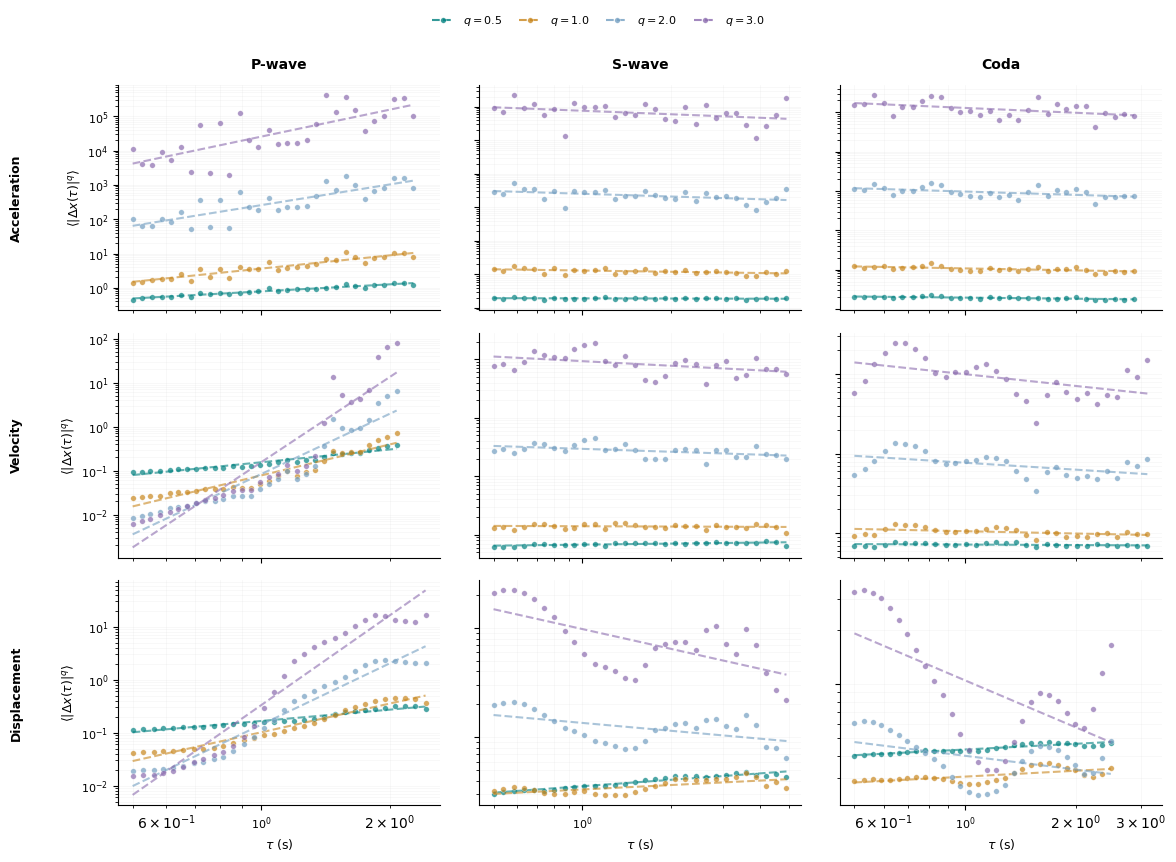

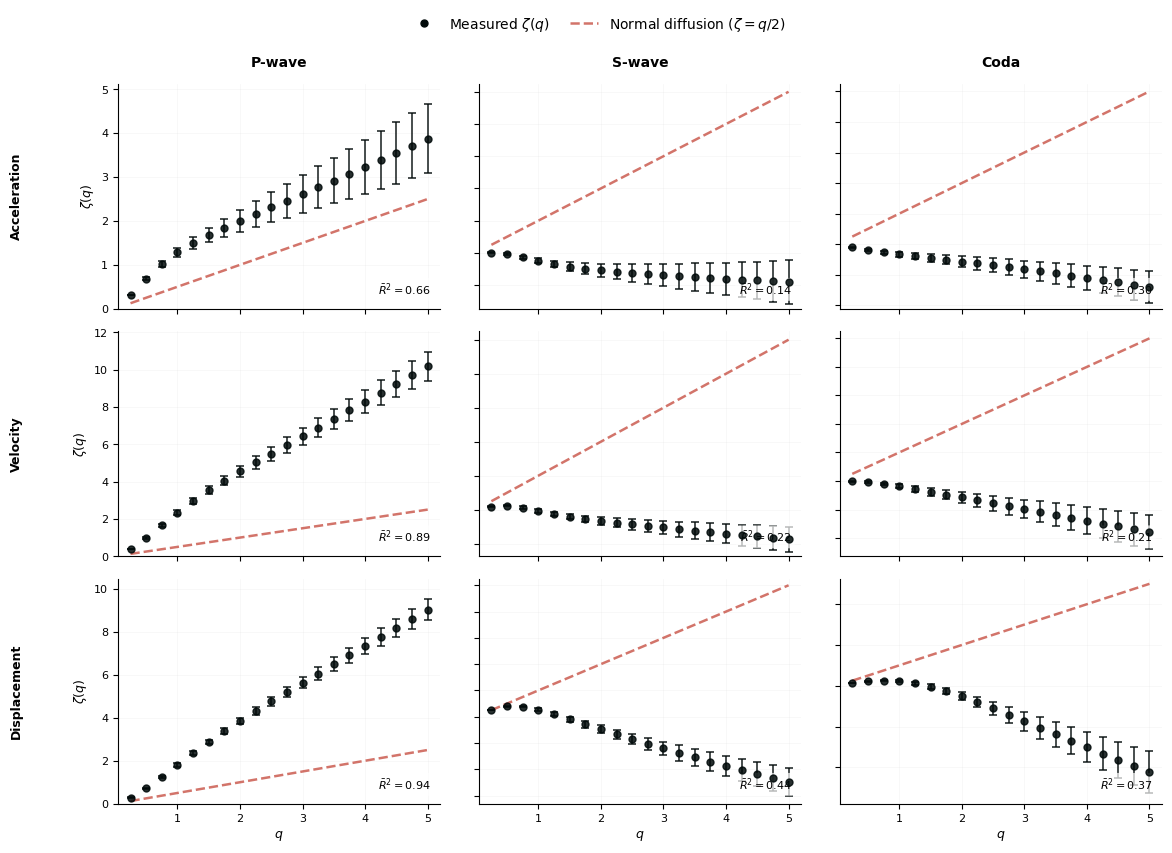

In [5]:
results_by_signal = load_scaling_results_by_signal(
    event_id=EVENT_ID,
    picker=PICKER,          
    config=CONFIG,
    coda_method=CODA_METHOD,
)

fig_curves = plot_scaling_curves_v2(
    results_by_signal=results_by_signal,
    coda_method=CODA_METHOD,
    output_path=FIGURES_SCALING / f'scaling_curves_{CODA_METHOD}',
    mode=MODE,
)

fig_exponents = plot_scaling_exponents_v2(
    results_by_signal=results_by_signal,
    coda_method=CODA_METHOD,
    output_path=FIGURES_SCALING/ f'scaling_exponents_{CODA_METHOD}',
    mode=MODE,
)
plt.show()